# RFM Segmentation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv(
    r"..\data\processed\online_retail_clean.csv",
    parse_dates=['InvoiceDate']
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Quarter,DAyOfWeek,Week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,4,Tuesday,49
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,4,Tuesday,49
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,4,Tuesday,49
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,4,Tuesday,49
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,4,Tuesday,49


In [2]:
# Define snapshot date

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [3]:
# Calculate RFM metrics

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice' : 'nunique',
    'Revenue': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice' : 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,17,-51.74
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,5,4404.54
12350,310,1,334.40


In [4]:
# Explore RFM distribution

rfm.describe().round(2)

,Recency,Frequency,Monetary
count,5939.00,5939.00,5939.00
mean,202.78,7.56,2742.88
std,211.73,15.97,13679.96
min,1.00,1.00,-25111.09
25%,25.00,2.00,321.36
50%,96.00,4.00,823.53
75%,381.00,8.00,2143.28
max,739.00,510.00,570380.61


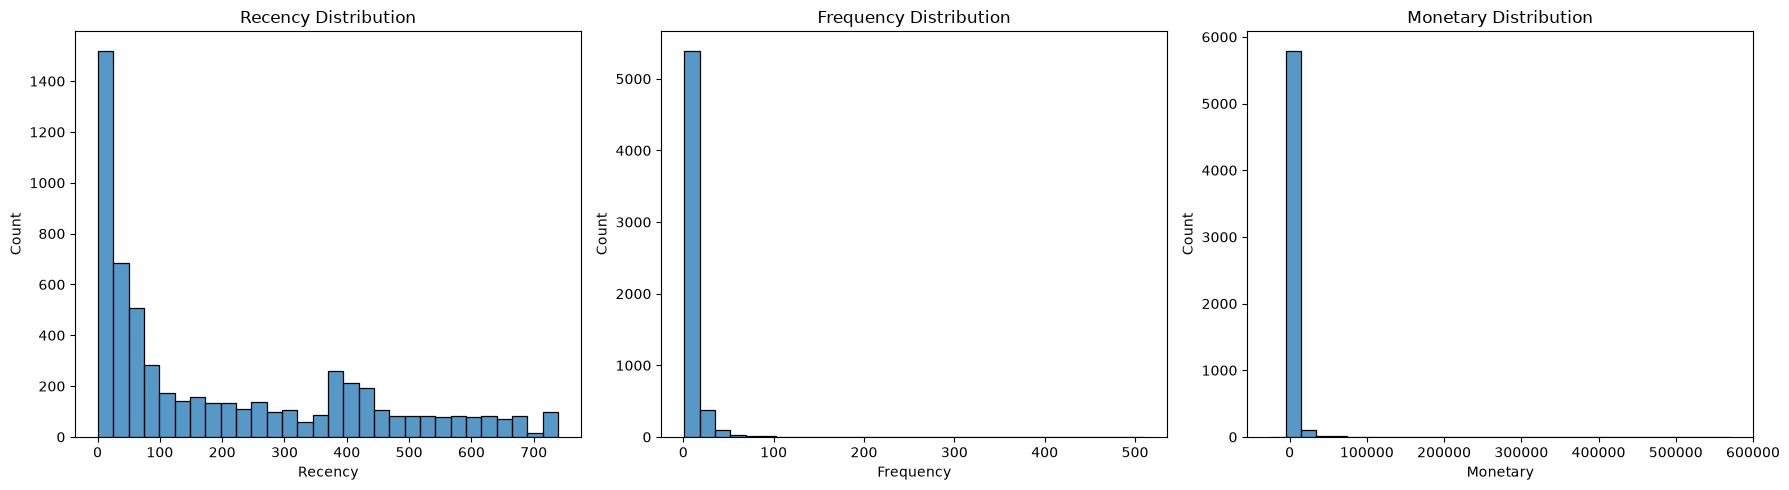

In [5]:
# Visualize RFM metrics

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [6]:
# Create RFM scores

# Recency Score
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=4,
    labels=[4, 3, 2, 1]
)

# Frequency Score

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q = 4,
    labels=[1, 2, 3, 4]
)

# Monetary score

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q = 4,
    labels=[1, 2, 3, 4]
)

In [7]:
# Create combined RFM Score

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,326,17,-51.74,2,4,1,241
12347,2,8,4921.53,4,3,4,434
12348,75,5,2019.40,3,3,3,333
12349,19,5,4404.54,4,3,4,434
12350,310,1,334.40,2,1,2,212


In [8]:
# Create customer segments

def segment_customer(score):

    if score == '444':
        return 'Champions'
    
    elif score[0] == '4':
        return 'Loyal Customers'
    
    elif score[0] == '1':
        return 'At risk'
    
    else:
        return 'Potential Loyalists'
    
rfm['Segment'] = (
    rfm['RFM_Score']
    .apply(segment_customer)
)

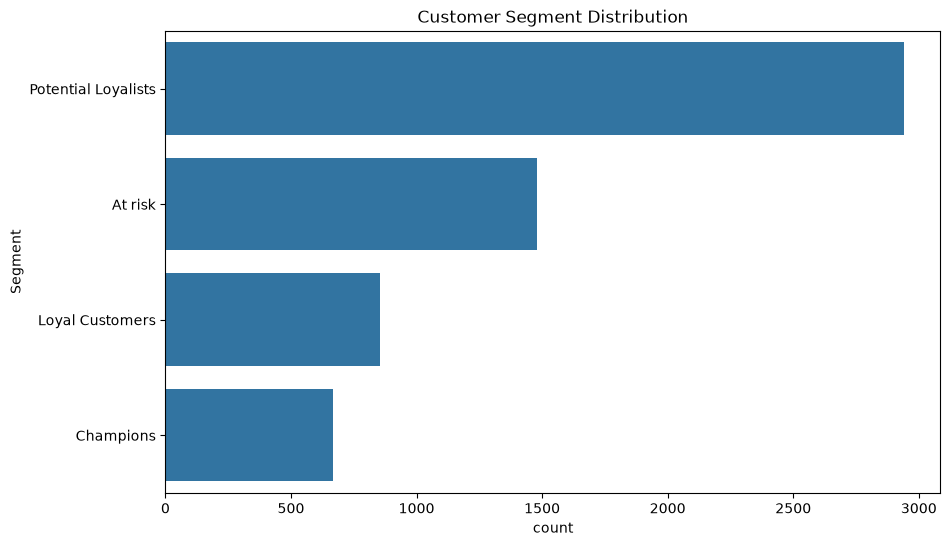

In [9]:
# Segmentation distribution

rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))

sns.countplot(
    data=rfm,
    y='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.title('Customer Segment Distribution')
plt.show()

In [10]:
# Segment Profiling

segment_profile = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At risk,519.38,2.30,539.09
Champions,9.51,29.97,13705.60
Loyal Customers,12.58,4.84,1224.27
Potential Loyalists,142.42,5.91,1809.69


In [11]:
# Remove negative Monetary values

print("Before:", rfm.shape)

rfm = rfm[rfm['Monetary'] > 0]

print("After:", rfm.shape)

Before: (5939, 8)
After: (5840, 8)


In [12]:
rfm.describe()

,Recency,Frequency,Monetary
count,5840.000000,5840.000000,5.840000e+03
mean,197.361815,7.646404,2.805245e+03
std,207.872880,16.086366,1.378176e+04
min,1.000000,1.000000,1.776357e-15
25%,24.000000,2.000000,3.363225e+02
50%,92.000000,4.000000,8.467450e+02
75%,376.000000,8.000000,2.180985e+03
max,739.000000,510.000000,5.703806e+05


In [16]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12347,2,8,4921.53,4,3,4,434,Loyal Customers
12348,75,5,2019.40,3,3,3,333,Potential Loyalists
12349,19,5,4404.54,4,3,4,434,Loyal Customers
12350,310,1,334.40,2,1,2,212,Potential Loyalists
12351,375,1,300.93,2,1,1,211,Potential Loyalists


In [14]:
print(rfm.shape)
print((rfm['Monetary'] < 0).sum())

(5840, 8)
0


In [17]:
rfm.to_csv(
    r"..\data\processed\rfm_dataset.csv",
    index=False
)

### RFM Analysis & Customer Segmentation Summary

1. Performed RFM (Recency, Frequency, Monetary) analysis to understand customer purchasing behavior and identify high-value customers.

2. Defined a snapshot date based on the latest transaction date in the dataset to calculate customer recency.

3. Calculated Recency as the number of days since a customer's last purchase, Frequency as the number of unique transactions, and Monetary as the total revenue generated by each customer.

4. Analyzed the distribution of RFM metrics and observed highly skewed customer behavior, indicating significant differences in customer engagement and spending patterns.

5. Identified customers with negative monetary values, which represented cases where total returns or refunds exceeded purchases. These customers were excluded from the segmentation process to avoid distorting customer value analysis.

6. Assigned quartile-based scores to Recency, Frequency, and Monetary metrics to standardize customer evaluation.

7. Combined individual R, F, and M scores to create an overall RFM score for each customer.

8. Segmented customers into business-oriented groups such as Champions, Loyal Customers, Potential Loyalists, and At Risk customers.

9. Profiled each customer segment by analyzing average Recency, Frequency, and Monetary values.

10. Identified that the majority of customers belong to the Potential Loyalist segment, indicating significant opportunities for customer engagement and conversion.

11. Observed that Champion customers represent a small but highly valuable customer group contributing substantially to overall revenue.

12. Generated actionable business recommendations for each customer segment to support retention, marketing, and revenue growth strategies.

### Key Business Insights

• Most customers are Potential Loyalists, indicating strong opportunities for customer nurturing and engagement.

• Champion customers exhibit high purchase frequency, recent activity, and significant spending, making them ideal candidates for loyalty programs and premium offerings.

• At-Risk customers have not purchased recently and require targeted retention campaigns to reduce churn.

• Customer spending behavior is highly uneven, with a small percentage of customers contributing a substantial portion of total revenue.

• RFM analysis provides a simple yet powerful framework for customer segmentation and personalized marketing.